In [18]:
from copy import deepcopy
from scipy import stats
from scipy.spatial import cKDTree
import pandas as pd
import os
import numpy as np
from tqdm import tqdm
import networkx as nx
import random
from collections import defaultdict, Counter
from typing import Dict, List, Set, Tuple, Optional
from itertools import chain, product
import bisect
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")
seed = 1729928109

# Set the random seed for reproducibility
random.seed(seed)
np.random.seed(seed)

base_sparsified_path = r'/raid/t2/TGN_adv/sparsified_data'
dataset_name = 'enron'
is_bipartite = True

if dataset_name.lower() in ['wikipedia', 'mooc']:
    is_bipartite = True
else:
    is_bipartite=False

original_filename = rf'ml_{dataset_name}.csv'

print(os.path.join(base_sparsified_path, dataset_name, original_filename))

orig_df = pd.read_csv(os.path.join(base_sparsified_path, dataset_name, original_filename))
orig_df.drop(['Unnamed: 0'], axis=1, inplace=True)
orig_df.head()

/raid/t2/TGN_adv/sparsified_data/enron/ml_enron.csv


,u,i,ts,label,idx
0,115,170,0.0,0,1
1,115,170,0.0,0,2
2,115,124,529920.0,0,3
3,115,124,529920.0,0,4
4,115,124,533820.0,0,5


In [19]:
val_ratio = test_ratio = 0.15

val_time, test_time = list(np.quantile(orig_df.ts, [(1 - val_ratio - test_ratio), (1 - test_ratio)]))

train_graph_df = orig_df[orig_df['ts'] < val_time]

In [20]:
# sparsification 
sprs_type = 'ts_tpr_remove_TER'
upto = 0.7

sprs_filename = f'{dataset_name}_{sprs_type}_sparsified_{upto}.csv'
sprs_filename

full_sprs_filepath = os.path.join(base_sparsified_path, dataset_name, sprs_type, sprs_filename)

sprs_df = pd.read_csv(full_sprs_filepath)
# sprs_df.drop(['Unnamed: 0'], axis=1, inplace=True)
sprs_df.head()

,Unnamed: 0,u,i,ts,label,idx
0,232,156,115,15368340,0,233
1,233,156,115,15368340,0,234
2,236,156,115,15394500,0,237
3,237,156,115,15394500,0,238
4,238,156,115,15394500,0,239


In [34]:
from hh_attack_utils import find_missing_edges
print(orig_df['ts'].min(), orig_df['ts'].max())

print(sum(orig_df['ts'].isna()), len(orig_df['ts'].unique()), len(orig_df['ts']), len(orig_df['ts']) - orig_df['ts'].nunique())


all_missing_edges_df = find_missing_edges(orig_df, sprs_df, start_time=orig_df['ts'].min(), end_time=orig_df['ts'].max(), batch_size=1)
all_missing_edges = all_missing_edges_df[0]

0.0 113740399.0
0 22632 125235 102603


## Run this

In [22]:
from hh_attack_data import add_negative_samples

In [ ]:
len()

In [23]:
negative_samples = add_negative_samples(sprs_df, train_graph_df, orig_df, is_bipartite)

Processing batch 1


	Selecting edges:  91%|█████████████████▎ | 5972/6572 [00:02<00:00, 5270.77it/s]

	Starting recovery phase...
	Remaining edges: 469
	Recovery phase complete. Added 169 additional edges.


	Nodes used: 140
Processing batch 2


	Selecting edges:  57%|██████████▊        | 3721/6572 [00:00<00:00, 7947.92it/s]

...

	Starting recovery phase...
	Remaining edges: 3577


	Recovery phase complete. Added 878 additional edges.
	Nodes used: 132
Processing batch 4


	Selecting edges:  23%|████              | 1488/6574 [00:00<00:00, 14871.93it/s]

	Starting recovery phase...
	Remaining edges: 4632


	Recovery phase complete. Added 1486 additional edges.
	Nodes used: 129
Total missing edges identified: 26290
Total new negative edges generated: 18013


In [ ]:
class EdgeTimestampSelector:
   def __init__(self,
                feasible_edges_dict: Dict[Tuple[int, int], List[int]],
                original_df: pd.DataFrame,
                degree_dict: Dict[int, int],
                removed_edges: Set[Tuple[int, int]],
                src_nodes: Optional[Set[int]] = None,
                dst_nodes: Optional[Set[int]] = None,
                time_window: int = 1200
                ):
       self.feasible_edges_dict = feasible_edges_dict
       self.original_df = original_df
       self.degree_dict = degree_dict
       self.removed_edges = removed_edges
       self.is_bipartite = src_nodes is not None and dst_nodes is not None
       self.src_nodes: Set[int] = src_nodes if src_nodes is not None else set()
       self.dst_nodes: Set[int] = dst_nodes if dst_nodes is not None else set()
       self.time_window = time_window
       
       self.node_usage: Dict[int, int] = defaultdict(int)
       self.selected_pairs: List[Tuple[int, int, int]] = []
       self.remaining_capacity: Dict[int, int] = deepcopy(degree_dict)
       
       self.max_edges: int = self._calculate_edge_budget()
       self.node_to_edges: Dict[int, List[Tuple[int, int]]] = self._create_node_edge_mapping()
       self.feasible_adj_lists: Dict[int, Set[int]] = self._create_adj_lists()
           
   def _calculate_edge_budget(self) -> int:
       if self.is_bipartite:
           if not self.src_nodes: return 0
           src_sum = sum(self.degree_dict.get(n, 0) for n in self.src_nodes)
           return src_sum
       return sum(self.degree_dict.values()) // 2
       
   def _create_node_edge_mapping(self) -> Dict[int, List[Tuple[int, int]]]:
       node_to_edges: Dict[int, List[Tuple[int, int]]] = defaultdict(list)
       for edge in self.feasible_edges_dict:
           u, v = edge
           node_to_edges[u].append(edge)
           node_to_edges[v].append(edge)
       return node_to_edges

   def _create_adj_lists(self) -> Dict[int, Set[int]]:
       adj_lists: Dict[int, Set[int]] = defaultdict(set)
       for (u, v) in self.feasible_edges_dict:
           adj_lists[u].add(v)
           if not self.is_bipartite: 
               adj_lists[v].add(u)
       return adj_lists
       
   def select_edges_timestamps(self) -> List[Tuple[int, int, int]]:
       priority_nodes = sorted(
           [n for n in self.degree_dict if self.degree_dict.get(n,0) > 0],
           key=lambda x: (self.degree_dict.get(x,0), -len(self.node_to_edges.get(x, []))),
           reverse=True
       )
       
       selected_count = 0
       pbar = tqdm(total=self.max_edges, desc="Selecting edges (Initial)", leave=False, ncols=100, unit="edge")
       
       for node in priority_nodes:
           if selected_count >= self.max_edges: break
           if self.remaining_capacity.get(node, 0) <= 0: continue
               
           while self.remaining_capacity.get(node, 0) > 0 and selected_count < self.max_edges:
               candidates = self._get_candidates(node)
               if not candidates: break
                   
               scored_candidates = [
                   (self._calculate_score(edge, timestamps), edge, timestamps) 
                   for edge, timestamps in candidates
               ]
               scored_candidates.sort(reverse=True)
               
               selected_one_for_node_this_iteration = False
               for _score, edge, timestamps in scored_candidates:
                   if self._can_select(edge, timestamps): 
                       best_timestamp = self._pick_best_timestamp(timestamps, edge)
                       self.selected_pairs.append((edge[0], edge[1], best_timestamp))
                       self._update_tracking(edge)
                       selected_count += 1
                       pbar.update(1)
                       selected_one_for_node_this_iteration = True
                       break 
                       
               if not selected_one_for_node_this_iteration: break 
       pbar.close()
       
       if selected_count < self.max_edges:
           print(f'\nInitial selection: {selected_count}/{self.max_edges} edges. Starting recovery phase...')
           remaining_needed = self.max_edges - selected_count
           
           recovery_pbar = tqdm(total=remaining_needed, desc="Selecting edges (Recovery)", leave=False, ncols=100, unit="edge")
           self._fast_recovery_phase(remaining_needed, self.original_df, recovery_pbar)
           recovery_pbar.close()
           print(f'Recovery phase complete. Total selected: {len(self.selected_pairs)}/{self.max_edges}')
       
       self._validate_selections()
       return self.selected_pairs
   
   def _fast_recovery_phase(self, needed_edges: int, original_df: pd.DataFrame, pbar: tqdm):
       """
       Recovery phase to find additional negative samples, respecting C3-like compliance.
       Allows the same (u,v) pair to be selected multiple times if different C3-compliant
       timestamps are found, and nodes have capacity. Prioritizes nodes with larger degree deficits.
       """
       additional_edges_added_in_recovery = 0
       
       df_sorted = original_df.sort_values('ts').set_index('ts')
       node_appearances: Dict[int, List[float]] = defaultdict(list)
       for ts_idx, row in df_sorted.iterrows():
           ts_val = float(ts_idx)
           node_appearances[row['u']].append(ts_val)
           if 'i' in row: node_appearances[row['i']].append(ts_val)
           elif 'v' in row: node_appearances[row['v']].append(ts_val)

       all_nodes_with_target_degree = self.degree_dict.keys()
       potential_src_candidates = self.src_nodes if self.is_bipartite else all_nodes_with_target_degree
       potential_dst_candidates = self.dst_nodes if self.is_bipartite else all_nodes_with_target_degree
       
       # These lists are dynamically pruned as nodes fill capacity
       available_src_nodes = [n for n in potential_src_candidates if self.remaining_capacity.get(n, 0) > 0]
       available_dst_nodes = [n for n in potential_dst_candidates if self.remaining_capacity.get(n, 0) > 0]

       # MODIFIED: Track selected (u,v,t) triplets
       current_selected_triplets: Set[Tuple[int, int, int]] = set(self.selected_pairs)
       
       all_timestamps = sorted(list(set(ts for ts_list in self.feasible_edges_dict.values() for ts in ts_list)))
       if not all_timestamps:
           print("\tWarning: No timestamps found in feasible_edges_dict for recovery phase.")
           return 

       window_cache: Dict[float, Set[int]] = {} 
       # Ensure time_window interpretation is correct for your 'ts' units
       # Assuming self.time_window is in seconds and original_df['ts'] is in milliseconds:
       window_size_val = self.time_window * 1000.0 
       # If self.time_window and original_df['ts'] are in the same units (e.g. seconds):
       # window_size_val = float(self.time_window)
       min_original_ts = float(df_sorted.index.min()) if not df_sorted.empty else 0.0

       # This set is updated if nodes are removed from available_src/dst_nodes
       active_nodes_for_cache_check = set(available_src_nodes) | set(available_dst_nodes)
       def get_nodes_in_window(timestamp: float) -> Set[int]:
           timestamp = float(timestamp) 
           if timestamp in window_cache: return window_cache[timestamp]
           window_start = max(timestamp - window_size_val, min_original_ts)
           nodes_in_window_result = set()
           for node in active_nodes_for_cache_check: 
               appearances = node_appearances.get(node, [])
               idx = bisect.bisect_left(appearances, window_start)
               if idx < len(appearances) and appearances[idx] <= timestamp:
                   nodes_in_window_result.add(node)
           window_cache[timestamp] = nodes_in_window_result
           return nodes_in_window_result

       batch_size = 200 
       newly_added_edges_in_recovery: List[Tuple[int, int, int]] = []
       random.shuffle(all_timestamps)

       for i in range(0, len(all_timestamps), batch_size):
           if additional_edges_added_in_recovery >= needed_edges: break
           batch_ts_list = all_timestamps[i:i + batch_size]
           
           for ts_val in batch_ts_list: get_nodes_in_window(float(ts_val))
           
           for timestamp_candidate_float in batch_ts_list:
               timestamp_candidate = int(timestamp_candidate_float) # Assuming timestamps are int after all
               if additional_edges_added_in_recovery >= needed_edges: break
                   
               active_nodes_this_ts = window_cache[timestamp_candidate_float]
               
               current_available_src_still_needed = [n for n in available_src_nodes if self.remaining_capacity.get(n,0) > 0]
               current_available_dst_still_needed = [n for n in available_dst_nodes if self.remaining_capacity.get(n,0) > 0]

               current_valid_src = [n for n in current_available_src_still_needed if n in active_nodes_this_ts]
               current_valid_dst = [n for n in current_available_dst_still_needed if n in active_nodes_this_ts]
               
               src_deficits = {n: self.degree_dict.get(n, 0) - self.node_usage.get(n,0) for n in current_valid_src}
               dst_deficits = {n: self.degree_dict.get(n, 0) - self.node_usage.get(n,0) for n in current_valid_dst}
               current_valid_src.sort(key=lambda n: src_deficits.get(n, 0), reverse=True)
               current_valid_dst.sort(key=lambda n: dst_deficits.get(n, 0), reverse=True)

               for src_node in current_valid_src:
                   if additional_edges_added_in_recovery >= needed_edges: break
                   if self.remaining_capacity.get(src_node,0) <= 0: continue 

                   for dst_node in current_valid_dst:
                       if additional_edges_added_in_recovery >= needed_edges: break
                       if self.remaining_capacity.get(dst_node,0) <= 0: continue
                       
                       if not self.is_bipartite and src_node == dst_node: continue

                       edge_pair = (src_node, dst_node) 
                       current_triplet_to_check = (src_node, dst_node, timestamp_candidate)
                       
                       if current_triplet_to_check in current_selected_triplets: continue
                       if edge_pair in self.removed_edges: continue
                        
                       if self.is_bipartite:
                           if not (src_node in self.src_nodes and dst_node in self.dst_nodes): continue
                       
                       if self._can_select(edge_pair, [timestamp_candidate]): 
                           newly_added_edges_in_recovery.append(current_triplet_to_check)
                           self._update_tracking(edge_pair) 
                           current_selected_triplets.add(current_triplet_to_check) 
                           
                           additional_edges_added_in_recovery += 1
                           pbar.update(1)
                           
                           if self.remaining_capacity.get(src_node,0) <= 0:
                               if src_node in available_src_nodes: available_src_nodes.remove(src_node)
                               active_nodes_for_cache_check.discard(src_node)
                               break 
                           if self.remaining_capacity.get(dst_node,0) <= 0:
                               if dst_node in available_dst_nodes: available_dst_nodes.remove(dst_node)
                               active_nodes_for_cache_check.discard(dst_node)
                               
           window_cache.clear() 
       
       self.selected_pairs.extend(newly_added_edges_in_recovery)

   def _get_candidates(self, node: int) -> List[Tuple[Tuple[int, int], List[int]]]:
       candidates = []
       for edge in self.node_to_edges.get(node, []): 
           timestamps = self.feasible_edges_dict.get(edge)
           if not timestamps: continue
           other_node = self._get_other_node(edge, node)
           if self.remaining_capacity.get(other_node, 0) > 0:
               candidates.append((edge, timestamps))
       return candidates

   def _get_other_node(self, edge: Tuple[int, int], node: int) -> int:
       u, v = edge
       return v if node == u else u
       
   def _calculate_score(self, edge: Tuple[int, int], timestamps: List[int]) -> float:
       u, v = edge
       remaining_cap_u = self.remaining_capacity.get(u, 0)
       remaining_cap_v = self.remaining_capacity.get(v, 0)
       score = (remaining_cap_u + remaining_cap_v + 
               len(timestamps) - 
               (self.node_usage.get(u, 0) + self.node_usage.get(v, 0)) * 10.0)
       if remaining_cap_u > 0 and remaining_cap_v > 0: score += 50.0 
       return score
       
   def _can_select(self, edge: Tuple[int, int], timestamps: List[int]) -> bool:
       u, v = edge
       if not timestamps: return False
       if self.remaining_capacity.get(u, 0) <= 0 or self.remaining_capacity.get(v, 0) <= 0: return False
       
       if self.is_bipartite:
           u_is_src = u in self.src_nodes; u_is_dst = u in self.dst_nodes
           v_is_src = v in self.src_nodes; v_is_dst = v in self.dst_nodes
           if (u_is_src and v_is_src) or (u_is_dst and v_is_dst): return False
           # Ensure edge connects one src to one dst. If nodes can be in NEITHER set, this is important.
           # if not ((u_is_src and v_is_dst) or (u_is_dst and v_is_src)): return False # This might be too strict if nodes can only be in one set or neither
       
       if edge in self.removed_edges: return False
       return True

   def _pick_best_timestamp(self, timestamps: List[int], edge: Tuple[int, int]) -> int:
       if not timestamps: raise ValueError(f"Cannot pick timestamp from empty list for edge {edge}")
       return max(timestamps) 

   def _update_tracking(self, edge: Tuple[int, int]):
       u, v = edge
       self.remaining_capacity[u] = self.remaining_capacity.get(u, 1) - 1
       self.remaining_capacity[v] = self.remaining_capacity.get(v, 1) - 1
       self.node_usage[u] = self.node_usage.get(u, 0) + 1
       self.node_usage[v] = self.node_usage.get(v, 0) + 1
       if self.remaining_capacity[u] < 0: self.remaining_capacity[u] = 0
       if self.remaining_capacity[v] < 0: self.remaining_capacity[v] = 0

   def _validate_selections(self):
       print("\n--- Validation ---")
       node_counts = defaultdict(int)
       unique_edge_triplets = set() # Now validating based on (u,v,t)
       
       for u_sel, v_sel, t_sel in self.selected_pairs:
           node_counts[u_sel] += 1
           node_counts[v_sel] += 1
           current_triplet = (u_sel, v_sel, t_sel)
           if current_triplet in unique_edge_triplets:
               print(f"\tERROR: Duplicate edge triplet selected: {current_triplet}") # Should not happen if logic is correct
           unique_edge_triplets.add(current_triplet)

       # Count unique (u,v) pairs to see pair diversity
       unique_edge_pairs = {(e[0], e[1]) for e in self.selected_pairs}
       print(f"\tTotal unique (u,v) pairs selected: {len(unique_edge_pairs)}")
       print(f"\tTotal unique edges (u,v,t) selected: {len(self.selected_pairs)} (Budget was: {self.max_edges})")
       
       over_capacity_nodes = []
       for node, count in node_counts.items():
           target_degree = self.degree_dict.get(node, 0)
           if count > target_degree:
               over_capacity_nodes.append((node, count, target_degree))
       
       if over_capacity_nodes:
           print("\tERROR: Nodes selected over their target degree:")
           for node, count, target in over_capacity_nodes: print(f"\t  Node {node}: Selected {count}, Target {target}")
       else: print("\tAll selected node degrees are within or at target capacity.")

       if self.is_bipartite:
           src_nodes_in_selection = {n for n in node_counts if n in self.src_nodes}
           dst_nodes_in_selection = {n for n in node_counts if n in self.dst_nodes}
           num_src_total = len(self.src_nodes) if self.src_nodes else 0
           num_dst_total = len(self.dst_nodes) if self.dst_nodes else 0
           print(f"\tSource nodes used in selection: {len(src_nodes_in_selection)} / {num_src_total}")
           print(f"\tDestination nodes used in selection: {len(dst_nodes_in_selection)} / {num_dst_total}")
       
       for u_sel, v_sel, t_sel in self.selected_pairs:
           if (u_sel, v_sel) in self.removed_edges:
               print(f"\tERROR: Edge pair ({u_sel},{v_sel}) from removed_edges was selected with timestamp {t_sel}!")
       print("--- End Validation ---")

## Checks

In [35]:
ns_df = pd.DataFrame(negative_samples, columns=['u', 'i', 'ts'])
ns_df.reset_index(drop=True, inplace=True)
ns_df.sort_values('ts', inplace=True)
ns_df.head()

,u,i,ts
5844,89.0,157.0,3.534513e+07
5841,89.0,157.0,3.534513e+07
5842,89.0,157.0,3.534513e+07
6105,157.0,39.0,3.534513e+07
5809,89.0,157.0,3.534513e+07


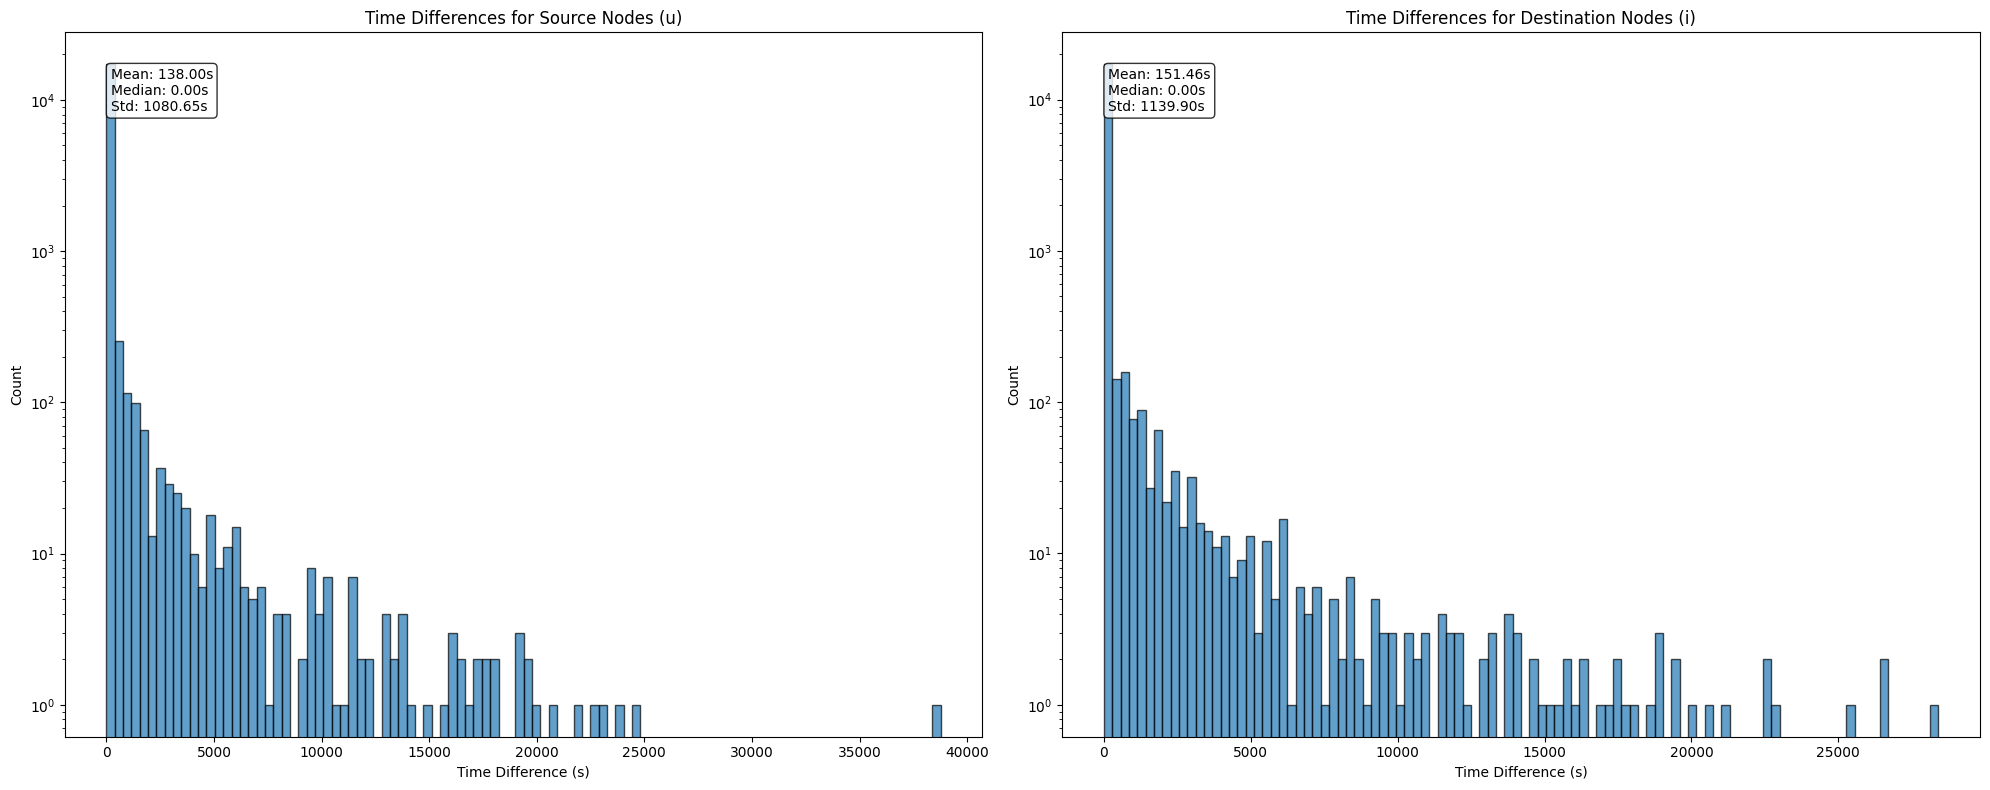

In [36]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot for source nodes (u)
ns_df_u = ns_df.sort_values(['u', 'ts'])
ns_df_u['diff'] = ns_df_u.groupby(['u'])['ts'].diff().fillna(0)
ts_diffs_u = ns_df_u['diff'].dropna()

ax1.hist(ts_diffs_u/1e3, bins=100, edgecolor='black', alpha=0.7, log=True)
ax1.set_ylabel('Count')
ax1.set_xlabel('Time Difference (s)')
ax1.set_title('Time Differences for Source Nodes (u)')

# Calculate and display statistics for u
mean_diff_u = ts_diffs_u.mean()
median_diff_u = ts_diffs_u.median()
std_diff_u = ts_diffs_u.std()

ax1.text(0.05, 0.95, f'Mean: {mean_diff_u/1e3:.2f}s\nMedian: {median_diff_u/1e3:.2f}s\nStd: {std_diff_u/1e3:.2f}s', 
         transform=ax1.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot for destination nodes (i)
ns_df_i = ns_df.sort_values(['i', 'ts'])
ns_df_i['diff'] = ns_df_i.groupby(['i'])['ts'].diff().fillna(0)
ts_diffs_i = ns_df_i['diff'].dropna()

ax2.hist(ts_diffs_i/1e3, bins=100, edgecolor='black', alpha=0.7, log=True)
ax2.set_ylabel('Count')
ax2.set_xlabel('Time Difference (s)')
ax2.set_title('Time Differences for Destination Nodes (i)')

# Calculate and display statistics for i
mean_diff_i = ts_diffs_i.mean()
median_diff_i = ts_diffs_i.median()
std_diff_i = ts_diffs_i.std()

ax2.text(0.05, 0.95, f'Mean: {mean_diff_i/1e3:.2f}s\nMedian: {median_diff_i/1e3:.2f}s\nStd: {std_diff_i/1e3:.2f}s', 
         transform=ax2.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

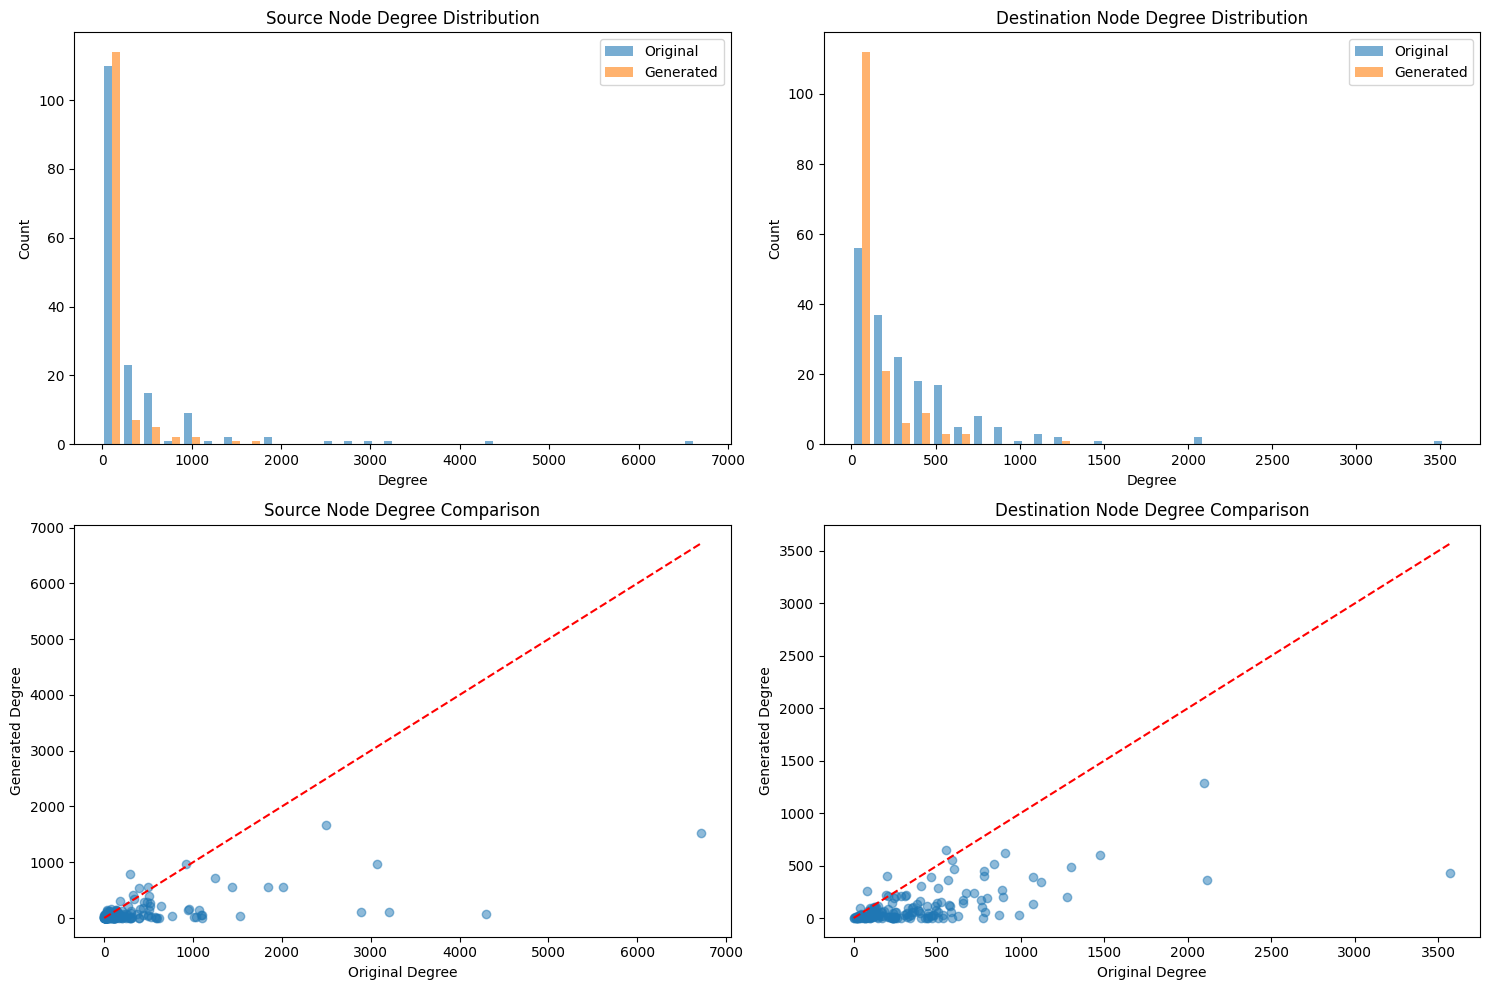

Source degree correlation: 0.638
Destination degree correlation: 0.637


In [37]:
def plot_degree_comparison(df1, df2, src_col='u', dst_col='i'):
    """
    Visualize degree distribution comparison between two DataFrames
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Calculate degree distributions
    src_degrees1 = Counter(df1[src_col])
    dst_degrees1 = Counter(df1[dst_col])
    src_degrees2 = Counter(df2[src_col])
    dst_degrees2 = Counter(df2[dst_col])
    
    # Plot 1: Source Node Degree Distribution
    degrees1 = list(src_degrees1.values())
    degrees2 = list(src_degrees2.values())
    ax1.hist([degrees1, degrees2], label=['Original', 'Generated'], 
             alpha=0.6, bins=30)
    ax1.set_title('Source Node Degree Distribution')
    ax1.set_xlabel('Degree')
    ax1.set_ylabel('Count')
    ax1.legend()
    
    # Plot 2: Destination Node Degree Distribution
    degrees1 = list(dst_degrees1.values())
    degrees2 = list(dst_degrees2.values())
    ax2.hist([degrees1, degrees2], label=['Original', 'Generated'], 
             alpha=0.6, bins=30)
    ax2.set_title('Destination Node Degree Distribution')
    ax2.set_xlabel('Degree')
    ax2.set_ylabel('Count')
    ax2.legend()
    
    # Plot 3: Source Node Degree Scatter
    x = sorted(set(src_degrees1.keys()) | set(src_degrees2.keys()))
    y1 = [src_degrees1.get(k, 0) for k in x]
    y2 = [src_degrees2.get(k, 0) for k in x]
    ax3.scatter(y1, y2, alpha=0.5)
    ax3.plot([0, max(max(y1), max(y2))], [0, max(max(y1), max(y2))], 'r--')
    ax3.set_title('Source Node Degree Comparison')
    ax3.set_xlabel('Original Degree')
    ax3.set_ylabel('Generated Degree')
    
    # Plot 4: Destination Node Degree Scatter
    x = sorted(set(dst_degrees1.keys()) | set(dst_degrees2.keys()))
    y1 = [dst_degrees1.get(k, 0) for k in x]
    y2 = [dst_degrees2.get(k, 0) for k in x]
    ax4.scatter(y1, y2, alpha=0.5)
    ax4.plot([0, max(max(y1), max(y2))], [0, max(max(y1), max(y2))], 'r--')
    ax4.set_title('Destination Node Degree Comparison')
    ax4.set_xlabel('Original Degree')
    ax4.set_ylabel('Generated Degree')
    
    plt.tight_layout()
    plt.savefig("BP_degree_dist.pdf", format="pdf", bbox_inches="tight")
    plt.show()
    
    # Additional statistics
    src_corr = np.corrcoef(
        [src_degrees1.get(k, 0) for k in x],
        [src_degrees2.get(k, 0) for k in x]
    )[0,1]
    dst_corr = np.corrcoef(
        [dst_degrees1.get(k, 0) for k in x],
        [dst_degrees2.get(k, 0) for k in x]
    )[0,1]
    
    print(f"Source degree correlation: {src_corr:.3f}")
    print(f"Destination degree correlation: {dst_corr:.3f}")
    

# use
plot_degree_comparison(all_missing_edges, ns_df)

In [ ]:
compliant = check_c3_compliance_optimized(all_missing_edges, new_edges)

plt.figure(figsize=(10, 6))
plt.plot(range(len(compliant)), compliant, 'b.')
plt.xlabel('Negative Sample Index')
plt.ylabel('C3 Compliant')
plt.title(f'C3 Compliance of Negative Samples: {sum(compliant)/len(compliant):.6%}')
plt.yticks([0, 1], ['No', 'Yes'])
plt.savefig("C3_Compliant.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
# TODO: Check for full dataset.
# TODO: Can we make it 100% C3 compliant?

In [ ]:
# TODO: Check for Tspear poisoned data also.
# TODO: Chekc if T-Spear is 100% compliant or not.